# Architecture

## Tokenisation + Data Loading

In [5]:
import os

from socrates_ai.data_prep import TheFarmer
from socrates_ai.oracle import Translator

farmer = TheFarmer()
tokeniser_path = os.path.join('..', 'data', 'tokenizer.json')

translator = Translator(cleaned_books_path = farmer.clean_dir)
oracle_tokens = translator.load_tokeniser(path=tokeniser_path)

In [6]:
import glob
import random

import torch


def load_book_paths(clean_dir):
    # sorted() so the file order is deterministic across runs -- without it,
    # glob's order isn't guaranteed, which would make the train/val split
    # below silently different every time we re-run this notebook
    return sorted(glob.glob(os.path.join(clean_dir, "*.txt")))


def tokenise_book(path, tokeniser):
    with open(path, encoding="utf-8") as f:
        text = f.read()
    ids = tokeniser.encode(text).ids

    bos_id = tokeniser.token_to_id("<bos>")
    eos_id = tokeniser.token_to_id("<eos>")
    # wrap each book in <bos>/<eos> before concatenating books together later --
    # without this the model would see one book's ending flow straight into the
    # next book's opening with no signal that anything changed
    return [bos_id] + ids + [eos_id]

In [7]:
def split_books_train_val(book_paths, tokeniser, val_fraction=0.1, seed=231103):
    # fixed seed -> same split every time we re-run the notebook, so results
    # are comparable across experiments instead of validating against a
    # different random slice of books each run
    rng = random.Random(seed)
    shuffled = book_paths.copy()
    rng.shuffle(shuffled)

    n_val = max(1, int(len(shuffled) * val_fraction))
    val_paths = shuffled[:n_val]
    train_paths = shuffled[n_val:]

    # held-out WHOLE books, not a slice cut out of one long token stream --
    # this tests whether the model generalises to material it has never seen
    # any part of, rather than just memorising continuations of familiar text
    train_ids = [tid for path in train_paths for tid in tokenise_book(path, tokeniser)]
    val_ids = [tid for path in val_paths for tid in tokenise_book(path, tokeniser)]

    # long tensor because these are token ids (indices into the embedding
    # table), not continuous values
    return (
        torch.tensor(train_ids, dtype=torch.long),
        torch.tensor(val_ids, dtype=torch.long),
    )

In [8]:
def get_batch(data, block_size, batch_size, device="cpu"):
    # -1 so the last possible start index still leaves room for y to grab
    # one extra token past the end of x (y is x shifted forward by one
    # position -- next-token prediction needs that overhang)
    max_start = len(data) - block_size - 1
    start_idx = torch.randint(0, max_start, (batch_size,))

    # x: block_size tokens starting at i | y: the same window shifted by
    # one position -- at every position, y is "the token that actually
    # came next", which is what the model is trained to predict
    x = torch.stack([data[i : i + block_size] for i in start_idx])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in start_idx])

    return x.to(device), y.to(device)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

book_paths = load_book_paths(farmer.clean_dir)
print(f"{len(book_paths)} cleaned books found")

train_ids, val_ids = split_books_train_val(book_paths, oracle_tokens)
print(f"train tokens: {len(train_ids):,}")
print(f"val tokens:   {len(val_ids):,}")

x, y = get_batch(train_ids, block_size=128, batch_size=64, device=device)
print(f"\nsample batch -> x: {tuple(x.shape)}, y: {tuple(y.shape)}")

Using device: cpu
50 cleaned books found
train tokens: 5,735,147
val tokens:   439,408

sample batch -> x: (64, 128), y: (64, 128)


# Model

### The plan

A quick contrast with your GRU, since it motivates why the pieces below look the way they do: a GRU processes tokens **one at a time**, carrying a single hidden state forward — that's why your old `forward(self, x, h=None)` takes and returns `h`. Everything the model "remembers" about the sequence so far has to be squeezed into that one fixed-size vector, and step `t` can't be computed until step `t-1` finishes.

A transformer processes the **whole sequence at once**, in parallel. Every position can look directly at every earlier position through self-attention, rather than relying on information having survived being compressed through a chain of hidden states. That's both faster to train (no sequential bottleneck) and avoids the "did this fact from 100 tokens ago survive the hidden state" problem RNNs are prone to.

The pieces, in the order we'll build them:
1. **`CausalSelfAttention`** — lets each position look at earlier positions
2. **`FeedForward`** — per-position processing on what attention found
3. **`TransformerBlock`** — combines the two with residual connections
4. **`MiniTransformer`** — embeddings in, a stack of blocks, output head out

In [9]:
import torch.nn as nn
import torch.nn.functional as F


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must divide evenly across heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        # one combined projection for Q, K and V instead of three separate
        # nn.Linear layers -- same result, fewer matmuls
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = dropout

    def forward(self, x):
        B, T, C = x.shape  # batch, sequence length, d_model

        q, k, v = self.qkv_proj(x).split(C, dim=-1)

        # split d_model into n_heads smaller heads, each attending to the
        # sequence independently -- lets the model track several different
        # kinds of relationships at once (e.g. grammar vs. long-range topic)
        # instead of one head having to represent everything
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B, n_heads, T, head_dim)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # is_causal=True masks out attention to future positions, so position t
        # can only look at positions <= t -- without this the model could
        # "cheat" during training by peeking at the very token it's supposed
        # to be predicting
        out = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=True
        )

        # merge the heads back into one d_model-sized vector per position
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)

In [10]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout):
        super().__init__()
        # expand to 4x d_model in the hidden layer -- standard transformer
        # choice, gives the model room to compute something more complex than
        # a linear function of what attention produced, then project back
        # down to d_model so it can be added back onto the residual stream
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, dropout)

    def forward(self, x):
        # pre-norm + residual: x = x + sublayer(norm(x)), rather than
        # normalising after the sublayer. This is the modern standard
        # (GPT-2 onwards) because gradients can flow straight through the "+"
        # in every layer, all the way back to the input -- stacking many
        # layers with post-norm is known to be much harder to train stably
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

### Putting it together — and a real gotcha with weight tying

Before the full model: a concrete reason to initialize weights explicitly rather than trusting PyTorch's defaults, discovered by actually testing this rather than assuming it'd be fine.

We're weight-tying the output head to the token embedding, as discussed earlier (`head.weight = token_emb.weight`) — reuse one matrix instead of learning two. The problem: PyTorch's default init for `nn.Embedding` uses a standard deviation of **1.0**, while `nn.Linear`'s default init scales down based on layer size (roughly **0.036** for a layer this size). Tying the two means the output head — which needs the smaller, `nn.Linear`-appropriate scale to produce sane logits — ends up using the much larger embedding-scale weights instead.

Concretely: I built this model, ran one untrained forward pass, and got a loss of **161** — when an untrained model over an 8,000-word vocabulary should score close to `ln(8000) ≈ 8.99` (equivalent to guessing uniformly at random). That gap is the tell. The fix is to explicitly re-initialize every `Linear`/`Embedding` weight to a small, fixed standard deviation (`0.02`, the GPT-2/nanoGPT convention) right after construction, rather than leaving the mismatched defaults in place. With that fix, the same untrained model scores `9.04` — right where it should be.

In [11]:
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_layers=4, n_heads=4, block_size=128, dropout=0.1):
        super().__init__()
        self.block_size = block_size

        self.token_emb = nn.Embedding(vocab_size, d_model)
        # a transformer has no built-in sense of order the way a GRU does
        # (which processes tokens one at a time, in sequence) -- positional
        # embeddings are how the model learns "this token is 1st / 5th / 100th"
        # at all, since attention alone treats the input as an unordered set
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)]
        )
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        # weight tying: reuse the token embedding matrix (transposed) as the
        # output projection instead of learning a second (vocab_size x d_model)
        # matrix from scratch -- saves a meaningful fraction of parameters for
        # a small model, standard practice since GPT-2
        self.head.weight = self.token_emb.weight

        # see the markdown above -- without this, the tied weights inherit
        # nn.Embedding's default init scale, which is far too large for an
        # output projection and badly inflates the loss
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.block_size, f"sequence length {T} exceeds block_size {self.block_size}"

        positions = torch.arange(T, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(positions)  # (B, T, d_model)
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.ln_final(x)
        logits = self.head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            # flatten batch and time together -- cross_entropy expects
            # (N, num_classes) predictions against (N,) targets, not a 3D tensor
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B * T, V), targets.view(B * T))

        return logits, loss

In [12]:
model = MiniTransformer(
    vocab_size=oracle_tokens.get_vocab_size(),
    d_model=256,
    n_layers=4,
    n_heads=4,
    block_size=128,
    dropout=0.1,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# sanity check against a real batch from the data loading section above --
# an untrained model should score close to ln(vocab_size), confirming the
# architecture and initialisation are both sane before we write a training loop
x, y = get_batch(train_ids, block_size=128, batch_size=64, device=device)
logits, loss = model(x, y)

print(f"logits shape: {tuple(logits.shape)}  (batch, block_size, vocab_size)")
print(f"loss at init: {loss.item():.4f}   (expect ~ln(vocab_size) = {torch.log(torch.tensor(oracle_tokens.get_vocab_size())).item():.4f})")

Total parameters: 5,240,320
logits shape: (64, 128, 8000)  (batch, block_size, vocab_size)
loss at init: 9.0398   (expect ~ln(vocab_size) = 8.9872)


## Training

Three pieces: a helper to measure loss without training on it (`estimate_loss`), the actual training loop (`train_model`), and a plot of how loss moved over the run.

In [13]:
@torch.no_grad()  # no gradients needed -- we're only measuring, not learning
def estimate_loss(model, data, block_size, batch_size, eval_iters, device):
    """
    Average loss over several random batches, rather than trusting a single
    batch -- one batch's loss is noisy (it depends on which random windows
    got sampled), averaging several gives a much more stable estimate.
    """
    model.eval()  # turns dropout off, so evaluation isn't affected by random dropping
    losses = torch.zeros(eval_iters)

    for i in range(eval_iters):
        x, y = get_batch(data, block_size, batch_size, device)
        _, loss = model(x, y)
        losses[i] = loss.item()

    model.train()  # switch dropout back on before returning to training
    return losses.mean().item()

In [14]:
import time


def train_model(
    model,
    train_ids,
    val_ids,
    block_size=128,
    batch_size=64,
    max_steps=300,
    eval_interval=30,
    eval_iters=10,
    lr=3e-4,
    device="cpu",
):
    """
    Standard training loop: sample a batch, compute loss, backpropagate,
    update weights -- repeated max_steps times. Every eval_interval steps,
    pause and record train/val loss so we can plot progress afterwards.
    """
    # AdamW: Adam with weight decay handled correctly (decoupled from the
    # gradient update) -- the standard optimizer choice for transformers
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    history = []
    start_time = time.time()

    for step in range(1, max_steps + 1):
        x, y = get_batch(train_ids, block_size, batch_size, device)
        logits, loss = model(x, y)

        # set_to_none=True is a small efficiency habit -- clears gradients by
        # dropping the tensors rather than zeroing them in place
        optimizer.zero_grad(set_to_none=True)
        loss.backward()   # backpropagation: compute gradients of loss w.r.t. every weight
        optimizer.step()  # apply those gradients -- this is the actual "learning" step

        # record progress at fixed intervals rather than every step -- estimate_loss
        # runs its own extra forward passes, so calling it every step would roughly
        # double the total training time for no real benefit
        if step % eval_interval == 0 or step == 1 or step == max_steps:
            train_loss = estimate_loss(model, train_ids, block_size, batch_size, eval_iters, device)
            val_loss = estimate_loss(model, val_ids, block_size, batch_size, eval_iters, device)
            history.append({"step": step, "train_loss": train_loss, "val_loss": val_loss})
            print(f"step {step:5d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

    elapsed = time.time() - start_time
    print(f"\nTraining finished in {elapsed:.1f}s")
    return history

### A note on runtime before you hit run

There's no CUDA or MPS available on this machine, so this trains on CPU. I benchmarked it: a single training step (forward + backward + optimizer update, at `batch_size=64`, `block_size=128`) takes about **2.7s** on this hardware. At the defaults below (`max_steps=300`, evaluating every 30 steps over `eval_iters=10` batches), the full run takes roughly **15-20 minutes**. Lower `max_steps` for a faster smoke test, or raise it for a more convincing loss curve — everything here is a plain function argument, nothing hardcoded.

In [15]:
# reuses the `model` instantiated earlier in the sanity-check cell -- still
# untrained at this point, that check only ran a forward pass, never called
# .backward() or an optimizer, so no learning has happened yet
history = train_model(model, train_ids, val_ids, device=device)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


step     1 | train loss 8.7233 | val loss 8.7556
step    30 | train loss 6.9954 | val loss 7.1738
step    60 | train loss 6.5458 | val loss 6.8526
step    90 | train loss 6.3036 | val loss 6.6178
step   120 | train loss 6.0484 | val loss 6.3679
step   150 | train loss 5.8711 | val loss 6.1601
step   180 | train loss 5.7081 | val loss 6.0760
step   210 | train loss 5.6247 | val loss 5.9218
step   240 | train loss 5.5371 | val loss 5.8338
step   270 | train loss 5.4553 | val loss 5.7892
step   300 | train loss 5.4088 | val loss 5.7817

Training finished in 3693.6s


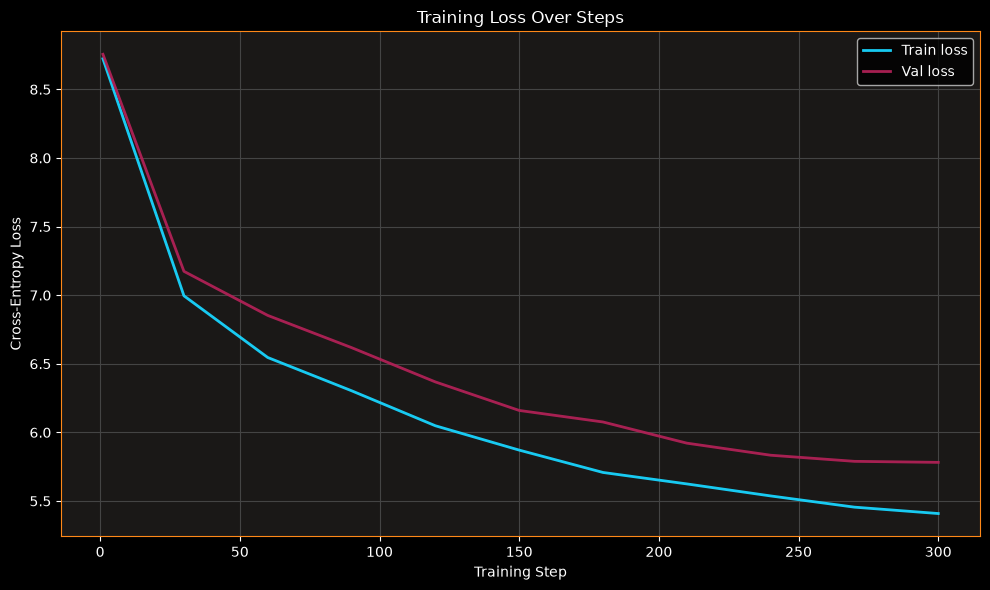

In [16]:
import matplotlib.pyplot as plt


def plot_training_curves(history):
    """Train vs. val loss over the course of training, CLAUDE.md dark style."""
    steps = [h["step"] for h in history]
    train_losses = [h["train_loss"] for h in history]
    val_losses = [h["val_loss"] for h in history]

    plt.style.use("dark_background")

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor("#000000")
    ax.set_facecolor("#1A1817")

    ax.plot(steps, train_losses, color="#18D5FFFF", alpha=0.95, linewidth=2, label="Train loss")
    ax.plot(steps, val_losses, color="#B02156FF", alpha=0.95, linewidth=2, label="Val loss")

    ax.grid(True, color="#444444", linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_color("#FF8818")

    ax.set_title("Training Loss Over Steps")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

## Generation

To answer the question directly first: **yes, we need an explicit cap on output length.** Generation is autoregressive — feed in a prompt, predict the next token, append it, feed the whole thing back in, predict again — and nothing about that loop naturally terminates on its own. Without a hard stop, it would just keep generating forever. `max_new_tokens` below is that hard stop.

There's also a second, more subtle limit specific to this architecture: `pos_emb` only has `block_size=128` rows (from a few turns back), so the model *cannot* be handed more than 128 tokens of context at once — there's no positional embedding for position 128+. As the generated sequence grows past that, `generate` below always crops back to the most recent `block_size` tokens before each forward pass ("sliding window"). Your old GRU's `predict()` didn't need this — it only ever fed in one token at a time plus a carried hidden state `h`, so context length was never bounded. A transformer has no hidden state to carry, so every step re-processes actual token positions, and that's exactly what makes the `block_size` cap necessary.

As a softer, optional stop: we trained `<eos>` to mark the end of a book, so if the model generates that token, `generate` can stop early rather than padding out to `max_new_tokens` regardless. Early in training this signal won't be reliable yet, but it costs nothing to have in place.

In [17]:
@torch.no_grad()  # generation is inference only -- no gradients needed
def generate(model, idx, max_new_tokens, block_size, device, temperature=1.0, eos_id=None):
    """
    Autoregressively extend `idx` (a (1, T) tensor of token ids) by up to
    max_new_tokens new tokens. Stops early if `eos_id` is produced.
    """
    model.eval()  # turn dropout off for generation, same reason as estimate_loss

    for _ in range(max_new_tokens):
        # crop to the last block_size tokens -- the model has no positional
        # embedding for anything beyond that, so this is required, not optional
        idx_cond = idx if idx.size(1) <= block_size else idx[:, -block_size:]

        logits, _ = model(idx_cond)  # (1, T, vocab_size)

        # only the LAST position's logits matter -- that's the prediction for
        # "what comes after everything we've fed in so far"
        last_logits = logits[:, -1, :] / temperature
        # temperature < 1 sharpens the distribution (more confident/repetitive),
        # > 1 flattens it (more random/varied) -- dividing before softmax is
        # what actually changes the shape of the resulting probabilities

        probs = F.softmax(last_logits, dim=-1)

        # sample rather than always taking the top prediction (argmax) -- greedy
        # decoding tends to get stuck in repetitive loops; sampling from the
        # full distribution gives varied, more natural-looking output
        next_id = torch.multinomial(probs, num_samples=1)

        idx = torch.cat([idx, next_id], dim=1)  # append and feed back in next iteration

        if eos_id is not None and next_id.item() == eos_id:
            break  # model signalled "this piece of writing is done"

    model.train()  # hand control back in training mode, matching estimate_loss's convention
    return idx

In [20]:
def talk(model, tokeniser, prompt, max_new_tokens=100, block_size=128, device="cpu", temperature=1.0, stop_at_eos=True):
    """
    User-facing wrapper: raw prompt string in, generated continuation string
    out. Handles the encode -> generate -> decode round trip so `generate`
    itself only has to deal with token ids.
    """
    prompt_ids = tokeniser.encode(prompt).ids
    idx = torch.tensor([prompt_ids], dtype=torch.long, device=device)  # (1, T) -- batch of 1

    eos_id = tokeniser.token_to_id("<eos>") if stop_at_eos else None

    out_ids = generate(model, idx, max_new_tokens, block_size, device, temperature, eos_id)
    return tokeniser.decode(out_ids[0].tolist())


print(talk(model, oracle_tokens, "life", max_new_tokens=60, block_size=128, device=device, temperature=0.8))

 life of the former, andThere is at a indivisible existence.


The English
Themiving that there is not, the first is the difference, there is:

      is the same
      _limocores forms to be such."
Nthropised and the degree of
